
E-Commerce 고객 행동 기반 구매 전환 분석 (다시 생각해야할듯)
===

## 0. 데이터 전처리
-----

### Import Packages

In [123]:
import pandas as pd
import numpy as np
from datetime import datetime

import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 모두다 나오게 출력
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

plt.rcParams['font.family'] = 'AppleGothic'
#plt.rcParams['font.family'] ='Malgun Gothic'   #window 용
plt.rcParams['axes.unicode_minus'] =False

### Load Tables


In [100]:

# 파일 로드
customer_raw = pd.read_csv('data/customer.csv')
product_raw = pd.read_csv('data/product.csv', on_bad_lines='skip')
transactions_raw = pd.read_csv('data/transactions.csv')
click_stream_raw = pd.read_csv('data/click_stream.csv')

customer = customer_raw.copy()
product = product_raw.copy()
transactions = transactions_raw.copy()
click_stream = click_stream_raw.copy()

### Explore Table


In [47]:
# Customer 테이블 기본 구조 확인
customer.info()
print(customer.shape)
print(customer.dtypes)
customer.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   customer_id         100000 non-null  int64  
 1   first_name          100000 non-null  str    
 2   last_name           100000 non-null  str    
 3   username            100000 non-null  str    
 4   email               100000 non-null  str    
 5   gender              100000 non-null  str    
 6   birthdate           100000 non-null  str    
 7   device_type         100000 non-null  str    
 8   device_id           100000 non-null  str    
 9   device_version      100000 non-null  str    
 10  home_location_lat   100000 non-null  float64
 11  home_location_long  100000 non-null  float64
 12  home_location       100000 non-null  str    
 13  home_country        100000 non-null  str    
 14  first_join_date     100000 non-null  str    
dtypes: float64(2), int64(1), str(12)
memory usage:

,customer_id,first_name,last_name,username,email,gender,birthdate,device_type,device_id,device_version,home_location_lat,home_location_long,home_location,home_country,first_join_date
0,2870,Lala,Maryati,671a0865-ac4e-4dc4-9c4f-c286a1176f7e,671a0865_ac4e_4dc4_9c4f_c286a1176f7e@startupca...,F,1996-06-14,iOS,c9c0de76-0a6c-4ac2-843f-65264ab9fe63,iPhone; CPU iPhone OS 14_2_1 like Mac OS X,-1.043345,101.360523,Sumatera Barat,Indonesia,2019-07-21
1,8193,Maimunah,Laksmiwati,83be2ba7-8133-48a4-bbcb-b46a2762473f,83be2ba7_8133_48a4_bbcb_b46a2762473f@zakyfound...,F,1993-08-16,Android,fb331c3d-f42e-40fe-afe2-b4b73a8a6e25,Android 2.2.1,-6.212489,106.818850,Jakarta Raya,Indonesia,2017-07-16
2,7279,Bakiman,Simanjuntak,3250e5a3-1d23-4675-a647-3281879d42be,3250e5a3_1d23_4675_a647_3281879d42be@startupca...,M,1989-01-23,iOS,d13dde0a-6ae1-43c3-83a7-11bbb922730b,iPad; CPU iPad OS 4_2_1 like Mac OS X,-8.631607,116.428436,Nusa Tenggara Barat,Indonesia,2020-08-23


In [38]:
# product 테이블 기본 구조 확인
product.info()
print(product.shape)
print(product.dtypes)
product.head(3)


<class 'pandas.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  str    
 2   masterCategory      44424 non-null  str    
 3   subCategory         44424 non-null  str    
 4   articleType         44424 non-null  str    
 5   baseColour          44409 non-null  str    
 6   season              44403 non-null  str    
 7   year                44423 non-null  float64
 8   usage               44107 non-null  str    
 9   productDisplayName  44417 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 3.4 MB
(44424, 10)
id                      int64
gender                    str
masterCategory            str
subCategory               str
articleType               str
baseColour                str
season                    str
year                  float64
usag

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch


In [39]:
# transactions 테이블 기본 구조 확인
transactions.info()
print(transactions.shape)
print(transactions.dtypes)
transactions.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 852584 entries, 0 to 852583
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   created_at              852584 non-null  str    
 1   customer_id             852584 non-null  int64  
 2   booking_id              852584 non-null  str    
 3   session_id              852584 non-null  str    
 4   product_metadata        852584 non-null  str    
 5   payment_method          852584 non-null  str    
 6   payment_status          852584 non-null  str    
 7   promo_amount            852584 non-null  int64  
 8   promo_code              326536 non-null  str    
 9   shipment_fee            852584 non-null  int64  
 10  shipment_date_limit     852584 non-null  str    
 11  shipment_location_lat   852584 non-null  float64
 12  shipment_location_long  852584 non-null  float64
 13  total_amount            852584 non-null  int64  
dtypes: float64(2), int64(4), str(8)

,created_at,customer_id,booking_id,session_id,product_metadata,payment_method,payment_status,promo_amount,promo_code,shipment_fee,shipment_date_limit,shipment_location_lat,shipment_location_long,total_amount
0,2018-07-29T15:22:01.458193Z,5868,186e2bee-0637-4710-8981-50c2d737bc42,3abaa6ce-e320-4e51-9469-d9f3fa328e86,"[{'product_id': 54728, 'quantity': 1, 'item_pr...",Debit Card,Success,1415,WEEKENDSERU,10000,2018-08-03T05:07:24.812676Z,-8.227893,111.969107,199832
1,2018-07-30T12:40:22.365620Z,4774,caadb57b-e808-4f94-9e96-8a7d4c9898db,2ee5ead1-f13e-4759-92df-7ff48475e970,"[{'product_id': 16193, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,10000,2018-08-03T01:29:03.415705Z,3.013470,107.802514,155526
2,2018-09-15T11:51:17.365620Z,4774,6000fffb-9c1a-4f4a-9296-bc8f6b622b50,93325fb6-eb00-4268-bb0e-6471795a0ad0,"[{'product_id': 53686, 'quantity': 4, 'item_pr...",OVO,Success,0,NaN,10000,2018-09-18T08:41:49.422380Z,-2.579428,115.743885,550696


In [82]:
# click_stream 테이블 기본 구조 확인
click_stream.info(show_counts=True)
print(click_stream.shape)
print(click_stream.dtypes)
click_stream.head(3)


<class 'pandas.DataFrame'>
RangeIndex: 12833602 entries, 0 to 12833601
Data columns (total 6 columns):
 #   Column          Non-Null Count     Dtype              
---  ------          --------------     -----              
 0   session_id      12833602 non-null  str                
 1   event_name      12833602 non-null  str                
 2   event_time      12833602 non-null  datetime64[us, UTC]
 3   event_id        12833602 non-null  str                
 4   traffic_source  12833602 non-null  str                
 5   event_metadata  4289540 non-null   str                
dtypes: datetime64[us, UTC](1), str(5)
memory usage: 587.5 MB
(12833602, 6)
session_id                        str
event_name                        str
event_time        datetime64[us, UTC]
event_id                          str
traffic_source                    str
event_metadata                    str
dtype: object


,session_id,event_name,event_time,event_id,traffic_source,event_metadata
0,fb0abf9e-fd1a-44dd-b5c0-2834d5a4b81c,HOMEPAGE,2019-09-06 15:54:32.821085+00:00,9c4388c4-c95b-4678-b5ca-e9cbc0734109,MOBILE,NaN
1,fb0abf9e-fd1a-44dd-b5c0-2834d5a4b81c,SCROLL,2019-09-06 16:03:57.821085+00:00,4690e1f5-3f99-42d3-84a5-22c4c4d8500a,MOBILE,NaN
2,7d440441-e67a-4d36-b324-80ffd636d166,HOMEPAGE,2019-09-01 12:05:10.322763+00:00,88aeaeb5-ec98-4859-852c-8abb483faf31,MOBILE,NaN


### Preprocessing 


+ #### 날짜 타입 변경

In [101]:
# 날짜 Type 변경
customer['birthdate'] = pd.to_datetime(customer['birthdate'], errors='coerce')
transactions['created_at'] = pd.to_datetime(transactions['created_at'], errors='coerce')
transactions['shipment_date_limit'] = pd.to_datetime(transactions['shipment_date_limit'], errors='coerce')
click_stream['event_time'] = pd.to_datetime(click_stream['event_time'], errors='coerce')

In [102]:
customer.info()
transactions.info()
click_stream.info()
transactions.head()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   customer_id         100000 non-null  int64         
 1   first_name          100000 non-null  str           
 2   last_name           100000 non-null  str           
 3   username            100000 non-null  str           
 4   email               100000 non-null  str           
 5   gender              100000 non-null  str           
 6   birthdate           100000 non-null  datetime64[us]
 7   device_type         100000 non-null  str           
 8   device_id           100000 non-null  str           
 9   device_version      100000 non-null  str           
 10  home_location_lat   100000 non-null  float64       
 11  home_location_long  100000 non-null  float64       
 12  home_location       100000 non-null  str           
 13  home_country        100000 non-null  str 

,created_at,customer_id,booking_id,session_id,product_metadata,payment_method,payment_status,promo_amount,promo_code,shipment_fee,shipment_date_limit,shipment_location_lat,shipment_location_long,total_amount
0,2018-07-29 15:22:01.458193+00:00,5868,186e2bee-0637-4710-8981-50c2d737bc42,3abaa6ce-e320-4e51-9469-d9f3fa328e86,"[{'product_id': 54728, 'quantity': 1, 'item_pr...",Debit Card,Success,1415,WEEKENDSERU,10000,2018-08-03 05:07:24.812676+00:00,-8.227893,111.969107,199832
1,2018-07-30 12:40:22.365620+00:00,4774,caadb57b-e808-4f94-9e96-8a7d4c9898db,2ee5ead1-f13e-4759-92df-7ff48475e970,"[{'product_id': 16193, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,10000,2018-08-03 01:29:03.415705+00:00,3.013470,107.802514,155526
2,2018-09-15 11:51:17.365620+00:00,4774,6000fffb-9c1a-4f4a-9296-bc8f6b622b50,93325fb6-eb00-4268-bb0e-6471795a0ad0,"[{'product_id': 53686, 'quantity': 4, 'item_pr...",OVO,Success,0,NaN,10000,2018-09-18 08:41:49.422380+00:00,-2.579428,115.743885,550696
3,2018-11-01 11:23:48.365620+00:00,4774,f5e530a7-4350-4cd1-a3bc-525b5037bcab,bcad5a61-1b67-448d-8ff4-781d67bc56e4,"[{'product_id': 20228, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,0,2018-11-05 17:42:27.954235+00:00,-3.602334,120.363824,271012
4,2018-12-18 11:20:30.365620+00:00,4774,0efc0594-dbbf-4f9a-b0b0-a488cfddf8a2,df1042ab-13e6-4072-b9d2-64a81974c51a,"[{'product_id': 55220, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,0,2018-12-23 17:24:07.361785+00:00,-3.602334,120.363824,198753


+ #### 최근 동향을 파악하기 위해 4개년치 추출

In [104]:
# 4개년 계산
max_year = pd.to_datetime(transactions['created_at']).max().year  #2021
years = [max_year - i for i in range(4)]
start_year = min(years)

# 각 연도별 필터링
transactions = transactions[transactions['created_at'].dt.year >= start_year]
click_stream = click_stream[click_stream['event_time'].dt.year >= start_year]


In [105]:
# 결과 요약 출력
print("기준 연도:", years)
print("거래 수:", len(transactions))
print("클릭 로그 수:", len(click_stream))
print(transactions['created_at'].min())
print(click_stream ['event_time'].min())

기준 연도: [2022, 2021, 2020, 2019]
거래 수: 740513
클릭 로그 수: 11126385
2019-01-01 00:04:56.716253+00:00
2019-01-01 00:00:01.231240+00:00


+ #### 결측치 처리

In [106]:
#결측치 처리
transactions['promo_amount'] = transactions['promo_amount'].fillna(0)
transactions['promo_code'] = transactions['promo_code'].fillna('None')
click_stream['traffic_source'] = click_stream['traffic_source'].fillna('Unknown')

In [107]:
transactions.info()
click_stream.info(show_counts=True)

<class 'pandas.DataFrame'>
Index: 740513 entries, 5 to 852583
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   created_at              740513 non-null  datetime64[us, UTC]
 1   customer_id             740513 non-null  int64              
 2   booking_id              740513 non-null  str                
 3   session_id              740513 non-null  str                
 4   product_metadata        740513 non-null  str                
 5   payment_method          740513 non-null  str                
 6   payment_status          740513 non-null  str                
 7   promo_amount            740513 non-null  int64              
 8   promo_code              740513 non-null  str                
 9   shipment_fee            740513 non-null  int64              
 10  shipment_date_limit     740513 non-null  datetime64[us, UTC]
 11  shipment_location_lat   740513 non-null  f

+ #### 이상치처리
    결제 주체 신뢰성 확보를 위해 **만 10세 미만 데이터는 입력 오류로 판단**  
    분석 모수에서 제외

In [108]:
#이상치 처리
#나이 이상치 확인
customer['age'] = 2021 - customer['birthdate'].dt.year  #거래 기준 max날짜 기준
#display(customer)
print(customer['age'].max())
print(customer['age'].min())    #5 ->10
customer.loc[(customer['age'] < 10)] = np.nan
customer['age'].count()


67
5


np.int64(99794)

+ #### 필요컬럼 추가 ####
    1. Customer
        - 연령대그룹 : age_groups
    2. Transactions
        - 프로모션 사용 여부 :  promo_used
        - 거래 성공 여부 : is_success
        - 실제거래 금액 : total_non_promo

In [109]:
# Customer
bins = [0, 20, 30, 40, 50, 60, 200]
labels = ['10대', '20대', '30대', '40대', '50대', '60대+']
customer['age_group'] = pd.cut(
    customer['age'], bins=bins, labels=labels, right=False
)

In [110]:
# Transactions
transactions['promo_used'] = (transactions['promo_code'].str.lower() != 'none') | (transactions['promo_amount'] > 0)
transactions['is_success'] = (transactions['payment_status'] == 'Success').astype(int)
transactions['total_non_promo'] = transactions['total_amount'] - transactions['promo_amount']

In [111]:
#customer.head()
transactions.head()

,created_at,customer_id,booking_id,session_id,product_metadata,payment_method,payment_status,promo_amount,promo_code,shipment_fee,shipment_date_limit,shipment_location_lat,shipment_location_long,total_amount,promo_used,is_success,total_non_promo
5,2019-02-03 11:25:55.365620+00:00,4774,1ed58c46-67fb-4386-924b-983c74ccb4d7,7fa0b583-6d30-40bc-8b61-0f70f5bef30f,"[{'product_id': 59620, 'quantity': 1, 'item_pr...",Debit Card,Success,6369,WEEKENDMANTAP,5000,2019-02-07 10:41:59.997463+00:00,-3.602334,120.363824,181865,True,1,175496
6,2019-03-22 11:53:02.365620+00:00,4774,c0ced313-e6b1-4a2a-b21f-347eccda5f96,e140f1f1-6da1-42b3-b2d1-56ac6fc72d4a,"[{'product_id': 53136, 'quantity': 1, 'item_pr...",Credit Card,Success,0,None,10000,2019-03-27 14:40:13.181562+00:00,-7.712608,110.502877,306599,False,1,306599
7,2019-05-08 11:29:21.365620+00:00,4774,0ed6730f-a5db-4e40-9a54-c343474d872c,e7eff973-b499-4b8d-9892-89e67e5fd7d4,"[{'product_id': 14142, 'quantity': 1, 'item_pr...",Credit Card,Success,0,None,10000,2019-05-10 20:09:58.104955+00:00,3.293114,98.857043,153913,False,1,153913
8,2019-06-24 12:08:52.365620+00:00,4774,6edd9366-4788-4bbb-ae5b-744e45e6118d,0d20c278-e082-4f28-9afe-8b5907d7a284,"[{'product_id': 12282, 'quantity': 1, 'item_pr...",Credit Card,Success,4019,AZ2022,10000,2019-06-28 10:34:36.588498+00:00,-6.126016,106.779552,370757,True,1,366738
9,2019-08-10 12:14:24.365620+00:00,4774,771665e9-7df2-41c8-8168-16d5cdd407a1,f5352cdc-0e3c-4e77-af42-645501dcded4,"[{'product_id': 53051, 'quantity': 1, 'item_pr...",Credit Card,Success,9072,WEEKENDSERU,10000,2019-08-14 18:07:04.125993+00:00,-0.992004,114.438739,1295740,True,1,1286668


In [114]:
transactions.to_csv("output/transactions.csv", index=False, encoding='utf-8-sig')
click_stream.to_csv("output/click_stream.csv", index=False, encoding='utf-8-sig')
customer.to_csv("output/customer.csv", index=False, encoding='utf-8-sig')
product.to_csv("output/product.csv", index=False, encoding='utf-8-sig')

## 1. 비즈니스 문제 정의
-----

1) 월별 매출 추이 확인하기 

In [119]:
# 연-월 컬럼 추가 (예: 2023-11)
transactions['year_month'] = transactions['created_at'].dt.tz_localize(None).dt.to_period('M')

# 연월별 거래량과 매출 합계 집계
monthly_stats = (transactions.groupby('year_month').agg(
    order_cnt = ('created_at', 'count'),  # 거래 건수
    gross_revenue = ('total_amount', 'sum'),       # 총매출 합계
    net_revenue = ('total_non_promo', 'sum')       # 총매출 합계
    ).reset_index()
)
monthly_stats['aov'] = monthly_stats['gross_revenue']/monthly_stats['order_cnt']
monthly_stats['aov_net'] = monthly_stats['net_revenue']/monthly_stats['order_cnt']

# 결과 확인
display(monthly_stats)

,year_month,order_cnt,gross_revenue,net_revenue,aov,aov_net
0,2019-01,8067,4451220191,4432393593,551781.355027,549447.575679
1,2019-02,7539,4078335557,4060334304,540965.055976,538577.305213
2,2019-03,8800,4652533315,4632018880,528696.967614,526365.781818
3,2019-04,8683,4710749035,4690603959,542525.513647,540205.454221
4,2019-05,9320,5166810538,5144465086,554378.813090,551981.232403
5,2019-06,9025,4991920475,4970128188,553121.382271,550706.724432
6,2019-07,10440,5698289321,5673193292,545813.153352,543409.319157
7,2019-08,10459,5778618243,5754248632,552501.983268,550171.969787
8,2019-09,10546,5871310137,5846184855,556733.371610,554350.924995
9,2019-10,11006,5971461341,5945143547,542564.177812,540172.955388


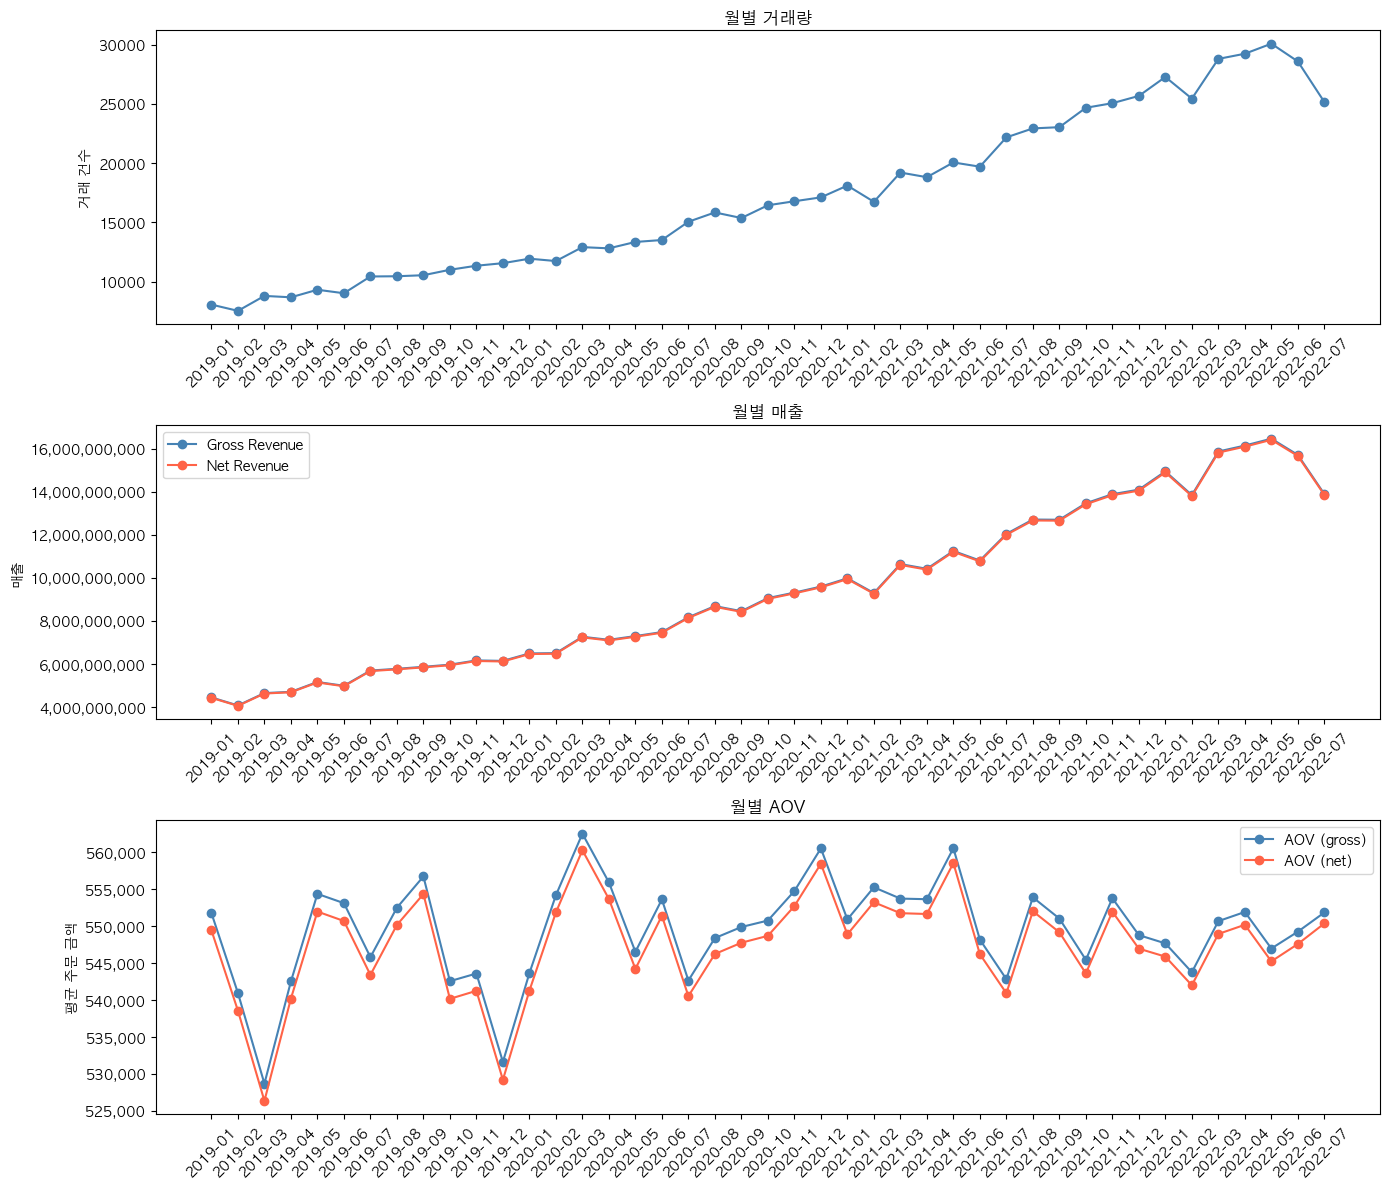

In [124]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
x = monthly_stats['year_month'].astype(str)

# 1. 월별 거래량
axes[0].plot(x, monthly_stats['order_cnt'], marker='o', color='steelblue')
axes[0].set_title('월별 거래량')
axes[0].set_ylabel('거래 건수')
axes[0].tick_params(axis='x', rotation=45)

# 2. 월별 매출 (gross vs net)
axes[1].plot(x, monthly_stats['gross_revenue'], marker='o', label='Gross Revenue', color='steelblue')
axes[1].plot(x, monthly_stats['net_revenue'],   marker='o', label='Net Revenue',   color='tomato')
axes[1].set_title('월별 매출')
axes[1].set_ylabel('매출')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# 3. AOV 추이
axes[2].plot(x, monthly_stats['aov'],     marker='o', label='AOV (gross)', color='steelblue')
axes[2].plot(x, monthly_stats['aov_net'], marker='o', label='AOV (net)',   color='tomato')
axes[2].set_title('월별 AOV')
axes[2].set_ylabel('평균 주문 금액')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
axes[2].legend()
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- 거래건수, 매출 : 2019년 이후 꾸준히 3배 이상 상승    
- AOV : 550,000원 내외에서 등락을 반복하며 **정체**
- Gross AOV vs Net AOV 간격 일정 : 프로모션 비용이 꾸준히 발생하고 있음

    ⇒ 매출 성장이 거래건수 증가에만 의존하고 있음  
    >   **AOV 정체의 원인 파악이 필요**

## 2. 가설 구조화
-----

- ###  AOV 정체의 원인을 3가지 가설로 구조화

    | 가설 | 내용 | 핵심 질문 |
    |------|------|---------|
    | A. 신규고객 증가 | 신규고객이 늘면서 AOV 평균을 끌어내림 | 신규 vs 재구매 고객의 AOV 차이가 있는가? |
    | B. 프로모션 구조 문제 | 프로모션 의존도가 높아져 AOV 희석 | 프로모션 사용 시 AOV가 낮아지는가? |
    | C. 고가 세그먼트 이탈 | 고가 상품 구매층이 이탈하고 있음 | 특정 연령대/퍼널에서 이탈이 발생하는가? |


#### A. 신규고객 증가로 AOV 평균이 낮아지는가?  
>        거래건수는 계속 오르는데 AOV는 정체  
>         → 새로운 고객이 계속 유입되고 있다는 신호  
>         → 신규고객은 보통 첫 구매라 소액 또는 탐색 구매를 하는 경향이 있음  
>         → 이게 AOV 평균을 끌어내릴 수 있다  

#### ⇒ 신규 vs 재구매 고객의 AOV 차이 비교

In [127]:
# 신규 고객 구분
# 1번 → 신규
# 2번 이상 → 재구매
transactions = transactions.sort_values('created_at')
transactions['purchase_rank'] = transactions.groupby('customer_id').cumcount() + 1
transactions['is_new'] = transactions['purchase_rank'] == 1

print(transactions['is_new'].value_counts())


is_new
False    692518
True      47995
Name: count, dtype: int64


In [147]:
# 연월별 거래량과 매출 합계 집계
monthly_segment = (transactions.groupby(['year_month', 'is_new']).agg(
    order_cnt = ('created_at', 'count'),  # 거래 건수
    gross_revenue = ('total_amount', 'sum'),       # 총매출 합계
    net_revenue = ('total_non_promo', 'sum'),       # 총매출 합계
    aov_mean=('total_amount', 'mean'),
    aov_median=('total_amount', 'median')
    ).reset_index()
)

monthly_segment['customer_type'] = monthly_segment['is_new'].map(
    {True: '신규', False: '재구매'}
)

# 결과 확인
display(monthly_segment)

,year_month,is_new,order_cnt,gross_revenue,net_revenue,aov_mean,aov_median,customer_type
0,2019-01,False,2199,1236476370,1231255427,562290.300136,310125.0,재구매
1,2019-01,True,5868,3214743821,3201138166,547843.186946,304550.5,신규
2,2019-02,False,4923,2677239299,2665457839,543822.729840,301780.0,재구매
3,2019-02,True,2616,1401096258,1394876465,535587.254587,302552.0,신규
4,2019-03,False,6826,3619917297,3603911162,530313.111192,296401.5,재구매
5,2019-03,True,1974,1032616018,1028107718,523108.418440,293060.0,신규
6,2019-04,False,7266,3951287435,3934523641,543805.041976,304387.0,재구매
7,2019-04,True,1417,759461600,756080318,535964.431898,302187.0,신규
8,2019-05,False,8046,4481618976,4462508753,556999.624161,301945.0,재구매
9,2019-05,True,1274,685191562,681956333,537826.971743,290744.0,신규


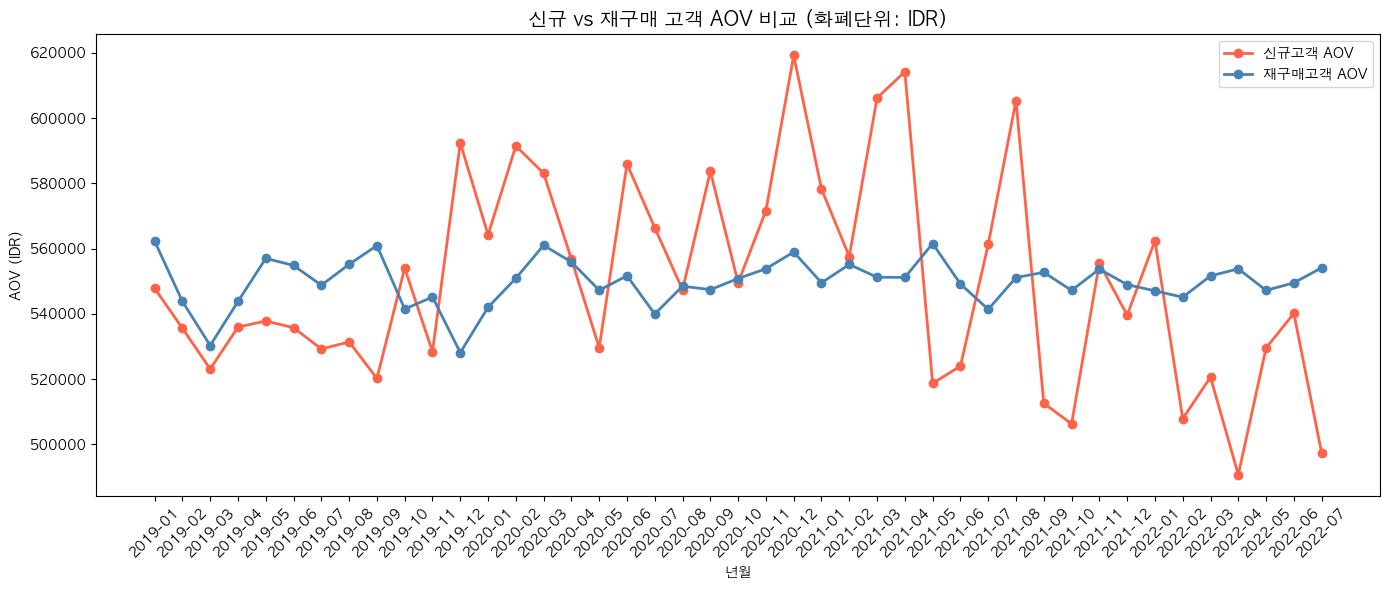

In [136]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# ── 차트 1 : 신규 vs 재구매 AOV (라인) ──────────────────
new_data = monthly_segment[monthly_segment['customer_type'] == '신규']
returning_data = monthly_segment[monthly_segment['customer_type'] == '재구매']

axes.plot(new_data['year_month'].astype(str), new_data['aov_mean'], marker='o', color="tomato", label='신규고객 AOV', linewidth=2)
axes.plot(returning_data['year_month'].astype(str), returning_data['aov_mean'], marker='o', color='steelblue', label='재구매고객 AOV', linewidth=2)

axes.set_title('신규 vs 재구매 고객 AOV 비교 (화폐단위: IDR)', fontsize=14)
axes.set_xlabel('년월')
axes.set_ylabel('AOV (IDR)')
axes.legend()

axes.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

#### 신규고객 AOV 등락이 심하다  
1. 신규고객이 프로모션에 반응해서 구매하는 건 아닐까?  
>    - 프로모션 있을 때 신규유입 → AOV 낮아짐  
>    -  프로모션 없을 때 신규유입 → AOV 높아짐  
  
2. 신규고객은 증가 하는가?  

In [ ]:
# 신규/재구매 고객의 프로모션 사용 여부
promo_segment = transactions.groupby(['is_new', 'promo_used']).agg(
    order_count=('created_at', 'count'),
    aov_mean=('total_amount', 'mean'),
    gross_revenue=('total_amount', 'sum')
).reset_index()

# 고객 타입별 전체 건수
total_by_type = transactions.groupby('is_new')['created_at'].count().reset_index()
total_by_type.columns = ['is_new', 'total_count']

promo_segment = promo_segment.merge(total_by_type, on='is_new')
#print(total_by_type)
#print(promo_segment)

promo_segment['promo_ratio'] = (
    promo_segment['order_count'] / promo_segment['total_count'] * 100
).round(2)

promo_segment['customer_type'] = promo_segment['is_new'].map(
    {True: '신규', False: '재구매'}
)
promo_segment['promo_type'] = promo_segment['promo_used'].map(
    {True: '사용', False: '미사용'}
)

print(promo_segment[['customer_type', 'promo_type', 'order_count', 'total_count', 'promo_ratio', 'aov_mean']])

  customer_type promo_type  order_count  total_count  promo_ratio  \
0           재구매        미사용       432931       692518        62.52   
1           재구매         사용       259587       692518        37.48   
2            신규        미사용        30954        47995        64.49   
3            신규         사용        17041        47995        35.51   

        aov_mean  
0  552194.979424  
1  546393.528027  
2  549386.801803  
3  545322.883986  


In [146]:
# 신규고객 비율이 증가하고 있는가?
monthly_new_ratio = transactions.groupby('year_month').agg(
    total=('created_at', 'count'),
    new=('is_new', 'sum')
).reset_index()
monthly_new_ratio['new_ratio'] = (monthly_new_ratio['new'] / monthly_new_ratio['total'] * 100).round(2)

print(monthly_new_ratio)

   year_month  total   new  new_ratio
0     2019-01   8067  5868      72.74
1     2019-02   7539  2616      34.70
2     2019-03   8800  1974      22.43
3     2019-04   8683  1417      16.32
4     2019-05   9320  1274      13.67
5     2019-06   9025   817       9.05
6     2019-07  10440  1589      15.22
7     2019-08  10459  1188      11.36
8     2019-09  10546  1086      10.30
9     2019-10  11006   936       8.50
10    2019-11  11347  1060       9.34
11    2019-12  11562   626       5.41
12    2020-01  11941   869       7.28
13    2020-02  11742   948       8.07
14    2020-03  12916   875       6.77
15    2020-04  12814   776       6.06
16    2020-05  13353   539       4.04
17    2020-06  13516   767       5.67
18    2020-07  15058  1536      10.20
19    2020-08  15843  1252       7.90
20    2020-09  15373  1041       6.77
21    2020-10  16449   905       5.50
22    2020-11  16788   885       5.27
23    2020-12  17115   447       2.61
24    2021-01  18110   872       4.82
25    2021-0

1. 신규고객이 프로모션에 반응해서 구매하는 건 아닐까?  
>    - 신규 / 재구매 고객의 프로모션 사용비율이 비슷하다.
>    - AOV가 프로모션 여부와 상관없이 비슷하다.
  
2. 신규고객은 증가 하는가?  
>    - 오히려 줄고 있다. 

#### ⇒ 재구매 고객은 늘고 있는데 왜 AOV 안 오르는지..

1. 재구매 횟수가 늘수록 AOV가 높아지는가?  
    - 오래된 고객일수록 더 많이 쓰는가?

2. 재구매 고객의 리텐션은 유지되고 있는가?  
    - 재구매는 하는데 구매 주기가 길어지는 건 아닌가?

In [155]:
# 재구매별 AOV
purchase_rank_aov = transactions.groupby('purchase_rank').agg(
    order_count=('created_at', 'count'),
    aov_mean=('total_amount', 'mean')
).reset_index()

# 구매 20회까지만 보기 (구매수가 많을수록 고객수가 줄어듦)
purchase_rank_aov = purchase_rank_aov[purchase_rank_aov['purchase_rank'] <= 20]

print(purchase_rank_aov)

    purchase_rank  order_count       aov_mean
0               1        47995  547943.876008
1               2        38810  551399.971245
2               3        33601  546603.667778
3               4        30000  554752.911867
4               5        27285  546941.135129
5               6        24965  549203.542319
6               7        23012  548207.201069
7               8        21335  547716.953176
8               9        19871  549995.114639
9              10        18608  554897.556051
10             11        17483  549749.425785
11             12        16495  565378.401273
12             13        15597  539340.195294
13             14        14777  564302.248021
14             15        13974  553950.105911
15             16        13290  548706.361776
16             17        12662  556708.255963
17             18        12077  547596.732384
18             19        11511  557477.171488
19             20        10957  555685.909008


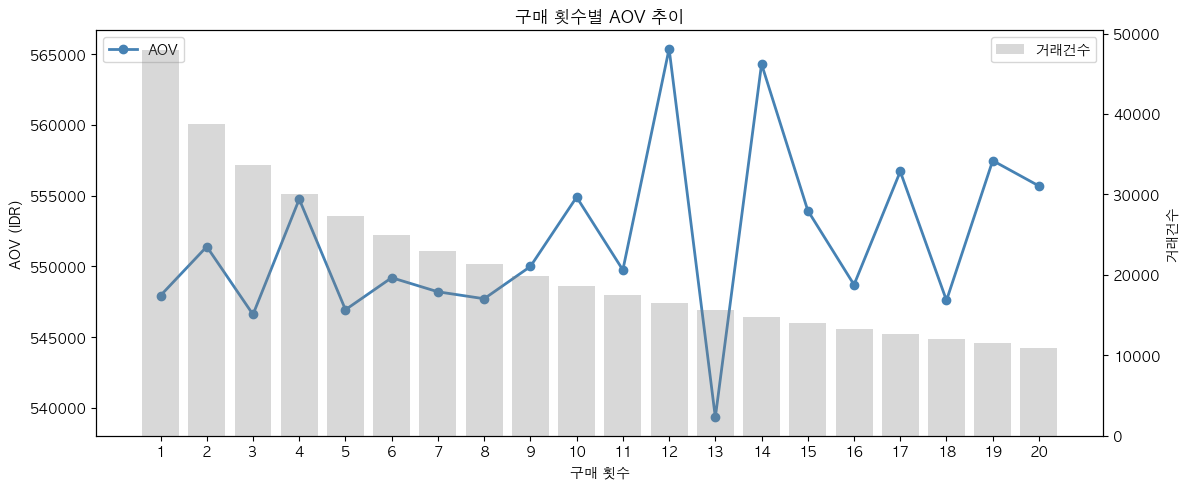

In [157]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# AOV 라인
ax1.plot(purchase_rank_aov['purchase_rank'],
         purchase_rank_aov['aov_mean'],
         marker='o', color='steelblue', linewidth=2, label='AOV')
ax1.set_xlabel('구매 횟수')
ax1.set_ylabel('AOV (IDR)')
ax1.set_title('구매 횟수별 AOV 추이')

# 거래건수 막대 (보조축)
ax2 = ax1.twinx()
ax2.bar(purchase_rank_aov['purchase_rank'],
        purchase_rank_aov['order_count'],
        alpha=0.3, color='gray', label='거래건수')
ax2.set_ylabel('거래건수')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

ax1.set_xticks(range(1, 21))
ax1.set_xticklabels(range(1, 21))

plt.tight_layout()
plt.show()

In [158]:
# 고객별 첫 구매 월 (코호트 기준)
customer_cohort = transactions.groupby('customer_id')['created_at'].min().reset_index()
customer_cohort.columns = ['customer_id', 'cohort_date']
customer_cohort['cohort_month'] = customer_cohort['cohort_date'].dt.to_period('M')

# 트랜잭션에 코호트 월 붙이기
transactions = transactions.merge(customer_cohort[['customer_id', 'cohort_month']], 
                                   on='customer_id', how='left')

# 구매 월
transactions['purchase_month'] = transactions['created_at'].dt.to_period('M')

# 코호트 기준 몇 번째 달인지
transactions['period_number'] = (
    transactions['purchase_month'] - transactions['cohort_month']
).apply(lambda x: x.n)

# 리텐션 테이블 생성
cohort_data = transactions.groupby(['cohort_month', 'period_number'])['customer_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot_table(index='cohort_month', 
                                        columns='period_number', 
                                        values='customer_id')

# 리텐션 비율
cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100
retention = retention.round(2)

/var/folders/s8/ydysgqf95zvfb85flggqqzlw0000gn/T/ipykernel_25031/616513150.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  customer_cohort['cohort_month'] = customer_cohort['cohort_date'].dt.to_period('M')
/var/folders/s8/ydysgqf95zvfb85flggqqzlw0000gn/T/ipykernel_25031/616513150.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  transactions['purchase_month'] = transactions['created_at'].dt.to_period('M')


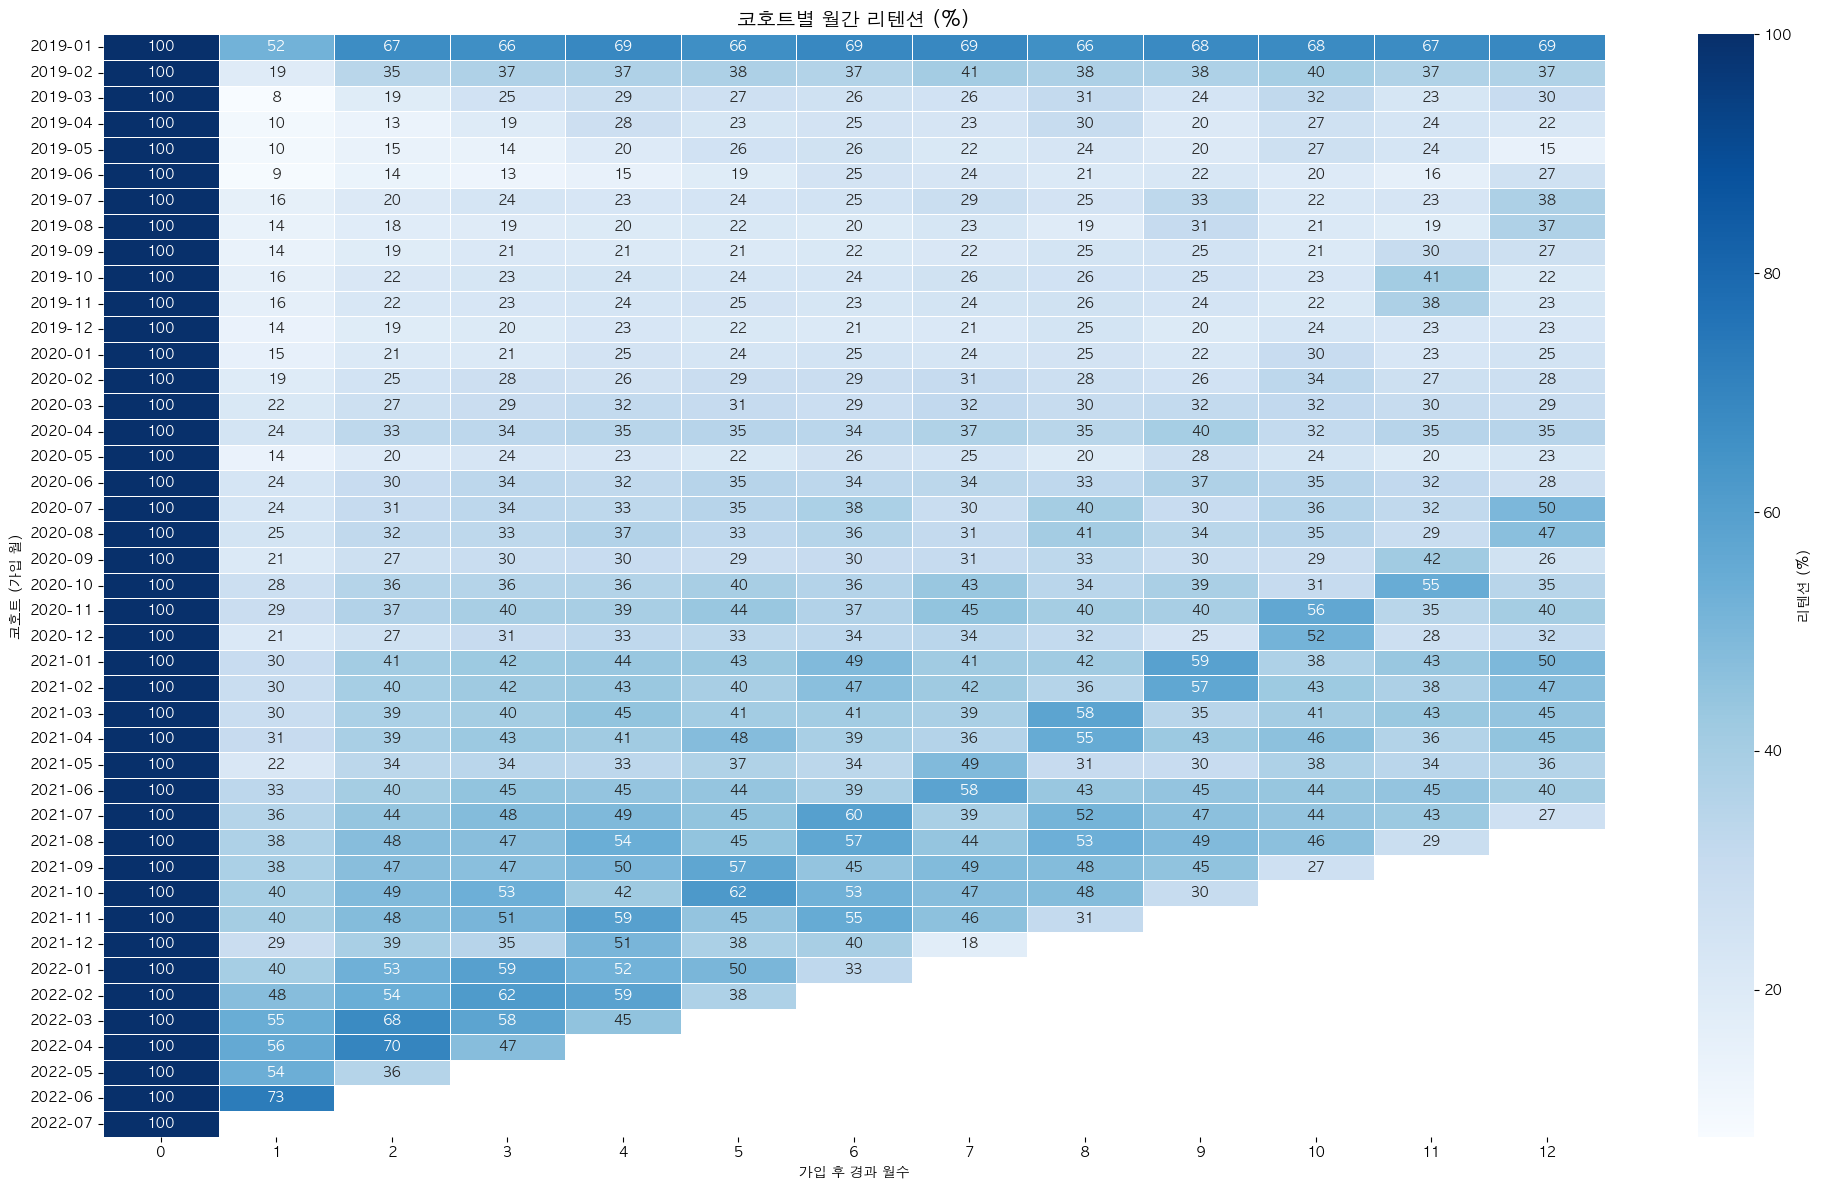

In [159]:
plt.figure(figsize=(20, 12))
sns.heatmap(retention.iloc[:, :13],  # 12개월까지만
            annot=True, fmt='.0f',
            cmap='Blues',
            linewidths=0.5,
            cbar_kws={'label': '리텐션 (%)'}
            )

plt.title('코호트별 월간 리텐션 (%)', fontsize=14)
plt.xlabel('가입 후 경과 월수')
plt.ylabel('코호트 (가입 월)')
plt.tight_layout()
plt.show()